# N10 — Memória em LangGraph

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Alejandro Núñez Arroyo <a href="mailto:r299215@dac.unicamp.br">(r299215@dac.unicamp.br)</a>
* Material base: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Este notebook trata da informação que um agente em LangGraph conserva de uma chamada para a seguinte. O estado de um grafo compilado sem persistência existe durante uma chamada a `invoke` e é descartado ao final dela. As seções acrescentam dois mecanismos de persistência: o **checkpointer**, que grava o estado de uma conversa identificada por um `thread_id`, e o **store**, que grava registros em namespaces lidos por qualquer conversa.

Antes deles, as seções 2 e 3 mostram como um valor externo ao estado chega a um nó, primeiro pelo `RunnableConfig` e depois pelo `Runtime` com um esquema de contexto. O `thread_id` que seleciona a conversa e o nome do aluno que seleciona o namespace chegam ao grafo por esses dois canais.

## 0.1 Pré-requisitos

Este notebook pressupõe os seguintes conhecimentos:

- Python: funções, dicionários, `dataclass`, anotações de tipo e f-strings;
- declaração de estado com `TypedDict` e construção de grafos com `StateGraph`, `add_node` e `add_edge`;
- associação de um reducer a um campo do estado com `Annotated`, em particular `add_messages`;
- chamada de um modelo de chat com uma lista de mensagens (`SystemMessage`, `HumanMessage`, `AIMessage`);
- `sqlite3`, o módulo da biblioteca padrão que lê e grava um banco de dados contido em um único arquivo.

## 0.2 Objetivos da aula

Objetivos deste notebook:

1. Verificar que o estado de um grafo sem persistência não passa de uma chamada a `invoke` para a seguinte.
2. Entregar valores externos ao estado a um nó pelo `RunnableConfig` e pelo `Runtime` com `context_schema`.
3. Persistir o estado de uma conversa entre chamadas com um checkpointer (`SqliteSaver`) e um `thread_id`.
4. Inspecionar os checkpoints gravados, pela API do grafo e pelo arquivo SQLite.
5. Gravar e ler registros entre conversas diferentes com um store (`SqliteStore`), organizados em namespaces.
6. Distinguir a memória organizada como perfil, um documento sobrescrito, da memória organizada como coleção de episódios, um documento por chave.
7. Compilar um grafo com checkpointer e store, em que um nó lê a memória do aluno e outro grava um episódio.

## 0.3 Mapa do notebook

Conteúdo deste notebook:

1. Estado de uma execução.
2. Configuração da execução.
3. Contexto tipado.
4. Memória de curto prazo.
5. Memória de longo prazo.
6. Agente com as duas memórias.
7. Exercícios de fixação.
8. Resumo da aula.
9. Referências.

## 0.4 Contexto usado nos exemplos

Os exemplos montam o tutor de um curso de agentes com LLMs, organizado em módulos (`A4`, `A5`, `A6`). Os alunos Renan e Ana conversam com o tutor em sessões separadas, e cada sessão corresponde a uma conversa com identificador próprio.

O tutor precisa de três informações que o texto da pergunta não traz: o que o aluno disse antes na mesma sessão, o módulo em que ele está e os assuntos das sessões anteriores. A primeira fica no checkpointer da seção 4. As duas outras ficam no store da seção 5, como perfil e como episódios.

---

## 0.5 Preparação do ambiente

O notebook usa o modelo `gpt-oss:120b`, executado na infraestrutura do Ollama e acessado pela API em `https://ollama.com`. Nenhum modelo é baixado na máquina. A seção 0.6 registra também a configuração do Gemini (`gemini-3.5-flash-lite`), para o caso de a execução ser feita pela API do Google. As chamadas de modelo deste notebook enviam uma lista de mensagens e leem o texto da resposta, sem tool calling nem saída estruturada.

As bibliotecas são `langchain` e `langgraph` (mensagens, grafo e `Runtime`), `langgraph-checkpoint-sqlite` (`SqliteSaver` e `SqliteStore`, os dois gravados em arquivo SQLite), `langchain-ollama` e `langchain-google-genai` (clientes dos dois provedores) e `python-dotenv` (leitura das chaves). A célula de imports carrega os dois clientes, então os dois pacotes precisam estar instalados; a constante `PROVEDOR` da seção 0.6 seleciona qual deles é instanciado.

O acesso ao modelo hospedado pelo Ollama exige uma chave de API. Os passos para obtê-la:

1. Criar uma conta em [ollama.com](https://ollama.com) e entrar nela.
2. Abrir [ollama.com/settings/keys](https://ollama.com/settings/keys) e gerar uma chave nova.
3. Copiar o valor exibido, que aparece uma única vez.
4. Guardar o valor na variável de ambiente `OLLAMA_API_KEY`.

Para o Gemini, a chave é gerada em [aistudio.google.com/apikey](https://aistudio.google.com/apikey) e guardada na variável `GOOGLE_API_KEY`. Há três formas de definir as variáveis. Em uma máquina local, escreva as linhas `OLLAMA_API_KEY=...` e `GOOGLE_API_KEY=...` em um arquivo `.env` ao lado do notebook, que já está no `.gitignore`, e deixe o `load_dotenv()` da seção 0.6 carregá-las. A segunda forma é exportar as variáveis no ambiente antes de abrir o notebook. A terceira é a célula comentada abaixo, para o Google Colab. Não escreva a chave no código versionado.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
# %pip install -U langchain langgraph langgraph-checkpoint-sqlite langchain-ollama langchain-google-genai python-dotenv

A célula a seguir cobre o caso do Google Colab, onde não há arquivo `.env`. Descomente as linhas, cole a chave entre as aspas e execute a célula. Torne a comentá-las antes de salvar o notebook, para que a chave não seja gravada no arquivo.

In [2]:
# # Descomente no Google Colab, onde não há arquivo .env.
# import os
# os.environ["OLLAMA_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""

Agora importamos os elementos que serão usados ao longo da aula.

In [3]:
import os
import sqlite3
import uuid

from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Annotated, TypedDict

from dotenv import load_dotenv

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.runtime import Runtime
from langgraph.store.base import BaseStore
from langgraph.store.sqlite import SqliteStore

from IPython.display import Image, display

Glossário dos imports:

- `os` e `load_dotenv`: leitura das chaves de API a partir do ambiente ou do arquivo `.env`;
- `sqlite3` e `Path`: abertura das conexões com os arquivos SQLite e remoção dos arquivos de uma execução anterior;
- `uuid`: geração de uma chave distinta para cada episódio gravado no store;
- `dataclass`: declaração do esquema de contexto da seção 3;
- `datetime`: carimbo de data e hora gravado junto ao perfil e aos episódios;
- `Annotated` e `TypedDict`: associação do reducer e declaração dos campos do estado;
- `AnyMessage`, `HumanMessage` e `SystemMessage`: tipo comum às mensagens, a fala do aluno e a instrução fixa do tutor;
- `RunnableConfig`: tipo do dicionário de configuração recebido por um nó na seção 2;
- `ChatOllama` e `ChatGoogleGenerativeAI`: clientes dos dois provedores configurados na seção 0.6;
- `SqliteSaver`: checkpointer que grava os checkpoints em um arquivo SQLite;
- `StateGraph`, `START` e `END`: construtor do grafo e os nós virtuais de entrada e saída;
- `add_messages`: reducer que acrescenta as mensagens novas à lista do estado;
- `CompiledStateGraph`, `Image` e `display`: tipo do grafo compilado e exibição do desenho dele;
- `Runtime`: objeto entregue ao nó com o contexto da execução e o store compilado com o grafo;
- `BaseStore` e `SqliteStore`: interface comum aos stores e a implementação que grava em arquivo SQLite.

As duas funções auxiliares abaixo são usadas nas células de exemplo. A primeira exibe o desenho de um grafo compilado; a segunda imprime o texto da última mensagem do resultado de um grafo de conversa.

In [4]:
def display_graph(graph: CompiledStateGraph) -> None:
    """Renderiza o grafo compilado como imagem PNG."""
    display(Image(graph.get_graph().draw_mermaid_png()))


def mostrar_resposta(resultado: dict) -> None:
    """Imprime o texto da última mensagem do estado final."""
    print(resultado["messages"][-1].text)

## 0.6 Escolhendo um provedor de LLM

O notebook instancia o modelo por uma função única, `criar_modelo`, e as seções seguintes chamam o objeto `modelo` devolvido por ela. A constante `PROVEDOR` seleciona qual cliente é construído.

Os dois provedores diferem nos pontos da tabela abaixo, e `criar_modelo` concentra os que afetam a construção do cliente:

| Ponto | Ollama | Gemini |
|---|---|---|
| Classe | `ChatOllama` | `ChatGoogleGenerativeAI` |
| Conexão | `base_url` em `https://ollama.com` e cabeçalho `Authorization` entregue por `client_kwargs` | chave entregue em `api_key` |
| Limite de tokens da resposta | `num_predict` | `max_output_tokens` |
| Amostragem | `temperature`, de 0 a 1 | fixa; a família Gemini 3.x não aceita `temperature`, `top_p` nem `top_k` |
| Raciocínio | `reasoning`, ligado ou desligado | `thinking_level`, com os valores `minimal`, `low`, `medium` e `high` |
| Campo `content` da resposta | uma string | uma lista de blocos |

A última linha define como o texto da resposta é lido. `mostrar_resposta` usa o atributo `.text` da mensagem, que devolve uma string nos dois provedores. O limite de tokens cobre o raciocínio e a resposta juntos, inclusive com `reasoning=False` no Ollama, e o valor 1500 de `LIMITE_RESPOSTA` cobre as respostas de três frases pedidas pela instrução do tutor.

As saídas gravadas neste arquivo vêm do Ollama. As células também foram executadas pelo `gemini-3.5-flash-lite`, e as leituras de execução descrevem o que as duas execuções têm em comum. Em uma das execuções pelo Gemini, a resposta do segundo turno da seção 6 trouxe no texto o raciocínio do modelo antes da resposta; seis chamadas seguintes com as mesmas mensagens não repetiram o caso. Para executar pelo Gemini, defina `GOOGLE_API_KEY` e troque o valor de `PROVEDOR`.

In [5]:
load_dotenv()

PROVEDOR = "ollama"  # troque para "gemini" depois de definir GOOGLE_API_KEY

MODELO_OLLAMA = "gpt-oss:120b"           # servido por https://ollama.com
MODELO_GEMINI = "gemini-3.5-flash-lite"  # servido pela API do Google AI Studio

URL_OLLAMA = "https://ollama.com"
TEMPERATURA = 0
LIMITE_RESPOSTA = 1500  # tokens gerados por chamada, raciocínio incluído


def criar_modelo() -> ChatOllama | ChatGoogleGenerativeAI:
    """Instancia o cliente do provedor escolhido com o mesmo orçamento de geração."""
    if PROVEDOR == "ollama":
        chave = os.environ.get("OLLAMA_API_KEY")
        if not chave:
            raise RuntimeError(
                "OLLAMA_API_KEY não encontrada. Gere uma chave em "
                "https://ollama.com/settings/keys e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        return ChatOllama(
            model=MODELO_OLLAMA,
            base_url=URL_OLLAMA,
            client_kwargs={"headers": {"Authorization": f"Bearer {chave}"}},
            reasoning=False,
            temperature=TEMPERATURA,
            num_predict=LIMITE_RESPOSTA,
        )

    if PROVEDOR == "gemini":
        chave = os.environ.get("GOOGLE_API_KEY")
        if not chave:
            raise RuntimeError(
                "GOOGLE_API_KEY não encontrada. Gere uma chave em "
                "https://aistudio.google.com/apikey e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        # A família Gemini 3.x fixa a amostragem, e temperature não é aceito.
        return ChatGoogleGenerativeAI(
            model=MODELO_GEMINI,
            api_key=chave,
            max_output_tokens=LIMITE_RESPOSTA,
            thinking_level="low",
        )

    raise RuntimeError(f"Provedor não reconhecido: {PROVEDOR}. Use 'ollama' ou 'gemini'.")


modelo = criar_modelo()

print(PROVEDOR, "|", type(modelo).__name__)

ollama | ChatOllama


---

# 1. Estado de uma execução

Um grafo compilado sem checkpointer cria o estado no início de cada chamada a `invoke`, a partir da entrada recebida, e devolve o estado final ao terminar. Nada desse estado é gravado fora da chamada. Uma segunda chamada parte apenas da entrada dela, mesmo que o campo `messages` use o reducer `add_messages`, porque o reducer acumula mensagens dentro de uma execução e não tem acesso a execuções anteriores.

```text
invoke(entrada 1) → estado 1 → responder → resultado 1   (estado 1 descartado)
invoke(entrada 2) → estado 2 → responder → resultado 2   (estado 2 começa só com a entrada 2)
```

O nó `responder` antepõe ao histórico uma instrução fixa, `INSTRUCAO_TUTOR`, e chama o modelo. A instrução é montada a cada chamada e não é devolvida pelo nó, então não entra no estado. O mesmo nó é reaproveitado na seção 4, sem alteração.

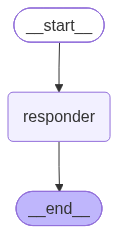

In [6]:
INSTRUCAO_TUTOR = (
    "Você é o tutor de um curso de agentes com LLMs. Responda em português, "
    "em no máximo três frases. Não invente dados sobre o aluno que não estejam na conversa."
)


class EstadoConversa(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


def responder(state: EstadoConversa) -> dict:
    """Chama o modelo com a instrução do tutor seguida do histórico do estado."""
    resposta = modelo.invoke([SystemMessage(content=INSTRUCAO_TUTOR), *state["messages"]])

    return {"messages": [resposta]}


builder = StateGraph(EstadoConversa)

builder.add_node("responder", responder)

builder.add_edge(START, "responder")
builder.add_edge("responder", END)

grafo_sem_memoria = builder.compile()

display_graph(grafo_sem_memoria)

As duas chamadas abaixo pertencem à mesma conversa do ponto de vista do aluno: a primeira informa o nome e o módulo, e a segunda pergunta por eles.

In [7]:
resultado_1 = grafo_sem_memoria.invoke(
    {"messages": [HumanMessage(content="Oi, meu nome é Renan e estou no módulo A6.")]}
)

mostrar_resposta(resultado_1)

Oi Renan! Que bom saber que você está no módulo A6. Como posso te ajudar hoje?


In [8]:
resultado_2 = grafo_sem_memoria.invoke(
    {"messages": [HumanMessage(content="Qual é o meu nome e em qual módulo eu estou?")]}
)

print("Mensagens no estado final:", len(resultado_2["messages"]))
mostrar_resposta(resultado_2)

Mensagens no estado final: 2
Não tenho essa informação. Poderia me dizer seu nome e em qual módulo está?


## 1.1 Leitura da execução

1. A primeira chamada cria um estado com uma `HumanMessage`, o nó `responder` acrescenta a `AIMessage`, e o estado final com duas mensagens é devolvido em `resultado_1`.
2. A segunda chamada cria um estado novo, com a pergunta como única mensagem. O estado final tem duas mensagens, a pergunta e a resposta.
3. O modelo recebe a instrução e a pergunta, sem a apresentação feita na primeira chamada, e responde que não tem o nome nem o módulo do aluno.

Para o modelo responder, a segunda chamada precisa receber as mensagens da primeira. As seções seguintes constroem as duas peças usadas para isso: um identificador da conversa entregue ao grafo junto com a entrada (seções 2 e 3) e um mecanismo que grava o estado sob esse identificador (seção 4).

---

# 2. Configuração da execução

Alguns valores de uma execução são definidos por quem chama o grafo e não mudam entre um nó e o seguinte, como o aluno que está conversando e a conversa em andamento. O `RunnableConfig` é o dicionário que leva esses valores até os nós. Ele é passado como segundo argumento de `invoke` ou `stream`, e os valores definidos pela aplicação ficam na chave `configurable`.

```text
config = {
    "configurable": {
        "thread_id": "renan-01",
        "aluno": "Renan",
    }
}
```

O LangGraph entrega esse dicionário ao nó que declara um parâmetro com o nome `config` e a anotação `RunnableConfig`. O nó abaixo lê o nome do aluno em `config["configurable"]`.

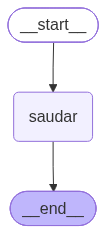

In [9]:
class EstadoSaudacao(TypedDict):
    mensagem: str


def saudar(state: EstadoSaudacao, config: RunnableConfig) -> dict:
    """Monta a saudação com o nome lido da configuração."""
    aluno = config["configurable"].get("aluno", "aluno")

    return {"mensagem": f"Olá, {aluno}! Pronto para continuar o curso?"}


builder = StateGraph(EstadoSaudacao)

builder.add_node("saudar", saudar)

builder.add_edge(START, "saudar")
builder.add_edge("saudar", END)

grafo_saudacao = builder.compile()

display_graph(grafo_saudacao)

O mesmo grafo é executado para dois alunos, com a entrada igual e a configuração diferente.

In [10]:
for aluno in ["Renan", "Ana"]:
    config = {"configurable": {"aluno": aluno}}
    resultado = grafo_saudacao.invoke({"mensagem": ""}, config)

    print(resultado["mensagem"])

Olá, Renan! Pronto para continuar o curso?
Olá, Ana! Pronto para continuar o curso?


## 2.1 Discussão

O nome do aluno poderia ser um campo de `EstadoSaudacao`. Os dois lugares diferem nos pontos da tabela:

| | Estado | `RunnableConfig` |
|---|---|---|
| Quem escreve | a entrada de `invoke` e os nós, pelo retorno | quem chama o grafo, uma vez por execução |
| Muda durante a execução | sim, a cada nó que devolve o campo | não |
| Aparece no resultado de `invoke` | sim | não |
| Gravado pelo checkpointer (seção 4) | sim, em `values` | fora do estado; os valores de `configurable` são copiados para o `metadata` de cada checkpoint |

O `thread_id` é o valor de `configurable` lido pelo LangGraph. Com um checkpointer compilado no grafo, ele seleciona a conversa cujo estado é carregado e gravado, como mostra a seção 4.

---

# 3. Contexto tipado

Um **esquema de contexto** declara os campos dos valores definidos pela aplicação. O esquema é passado a `StateGraph(..., context_schema=...)`, o valor é passado a `invoke` pelo parâmetro `context`, e o nó o lê no atributo `context` de um objeto `Runtime`. Os campos têm nome e tipo declarados, e a subseção 3.2 compara essa forma com a leitura de `config["configurable"]`.

```text
invoke(entrada, context=ContextoCurso(...))
        ↓
nó(state, runtime: Runtime[ContextoCurso]) → runtime.context.aluno
```

## 3.1 Declaração do contexto

O esquema abaixo é uma `dataclass` com dois campos, o nome do aluno e o idioma da saudação. O nó declara o parâmetro `runtime: Runtime[ContextoCurso]` e lê os campos como atributos. O LangGraph identifica esse parâmetro pelo nome `runtime`, e a anotação `Runtime[ContextoCurso]` informa ao editor o tipo de `runtime.context`.

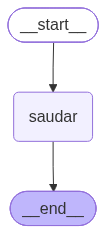

In [11]:
@dataclass
class ContextoCurso:
    aluno: str
    idioma: str = "pt"


def saudar_com_contexto(state: EstadoSaudacao, runtime: Runtime[ContextoCurso]) -> dict:
    """Monta a saudação no idioma definido pelo contexto."""
    aluno = runtime.context.aluno

    if runtime.context.idioma == "en":
        return {"mensagem": f"Hello, {aluno}! Ready to continue the course?"}

    return {"mensagem": f"Olá, {aluno}! Pronto para continuar o curso?"}


builder = StateGraph(EstadoSaudacao, context_schema=ContextoCurso)

builder.add_node("saudar", saudar_com_contexto)

builder.add_edge(START, "saudar")
builder.add_edge("saudar", END)

grafo_contexto = builder.compile()

display_graph(grafo_contexto)

O contexto é passado pelo parâmetro `context` de `invoke`, separado do `config`.

In [12]:
resultado_pt = grafo_contexto.invoke({"mensagem": ""}, context=ContextoCurso(aluno="Renan"))
resultado_en = grafo_contexto.invoke({"mensagem": ""}, context=ContextoCurso(aluno="Ana", idioma="en"))

print(resultado_pt["mensagem"])
print(resultado_en["mensagem"])

Olá, Renan! Pronto para continuar o curso?
Hello, Ana! Ready to continue the course?


## 3.2 Comparação das duas formas

| | `RunnableConfig` | `Runtime` e `context_schema` |
|---|---|---|
| Declaração do formato | nenhuma, `configurable` é um dicionário | `context_schema` no `StateGraph` |
| Leitura no nó | `config["configurable"]["chave"]` | `runtime.context.chave` |
| Passagem na chamada | `invoke(entrada, {"configurable": {...}})` | `invoke(entrada, context=ContextoCurso(...))` |
| Nome de campo errado na leitura | devolve o padrão de `.get` ou levanta `KeyError` | levanta `AttributeError`, e um verificador de tipos aponta o nome antes da execução |
| Valores lidos pelo LangGraph | `thread_id` e os demais identificadores da execução | nenhum |

A `dataclass` declara os campos, e o LangGraph converte em `ContextoCurso` um dicionário passado em `context`. O tipo dos campos não é verificado na execução: `ContextoCurso(aluno=3)` é aceito e o nó recebe o número. Um `invoke` sem o argumento `context` entrega `runtime.context` igual a `None`, e o nó falha no primeiro acesso a atributo.

O `thread_id` continua em `config["configurable"]`, porque o checkpointer o lê ali para selecionar a conversa carregada. Um nó que precise dele o encontra em `runtime.execution_info.thread_id`. A seção 6 usa as duas formas juntas: o `thread_id` no `config` e o nome do aluno no `context`. Um nó que precise dos dois objetos declara os dois parâmetros:

```python
def no(state: EstadoConversa, config: RunnableConfig, runtime: Runtime[ContextoCurso]) -> dict:
    ...
```

---

# 4. Memória de curto prazo

Um **checkpointer** grava um **checkpoint**, uma cópia do estado do grafo, ao fim de cada *super-step*, a rodada em que os nós ativos executam e as atualizações deles são aplicadas ao estado. Cada checkpoint fica associado ao `thread_id` do `config`. Uma chamada a `invoke` com um `thread_id` que já tem checkpoints carrega o último deles e aplica a entrada nova sobre esse estado pelos reducers. Com `add_messages`, a mensagem nova é acrescentada ao histórico gravado.

```text
thread_id "renan-01" → [checkpoint 0, checkpoint 1, checkpoint 2, ...]

invoke(entrada, {"configurable": {"thread_id": "renan-01"}})
  → carrega o último checkpoint de "renan-01"
  → add_messages acrescenta a entrada ao histórico
  → responder
  → grava um checkpoint novo em "renan-01"
```

A documentação do LangGraph chama isso de memória de **curto prazo**: o escopo é uma thread, que corresponde a uma conversa. Duas threads diferentes não compartilham checkpoints.

## 4.1 Criação do `SqliteSaver`

O `SqliteSaver` grava os checkpoints em um arquivo SQLite, aberto com `sqlite3.connect`. A célula apaga o banco de uma execução anterior antes de abrir a conexão; sem isso, as threads `renan-01` e `ana-01` já teriam mensagens na segunda execução do notebook, e as saídas desta seção mudariam. O `SqliteSaver` ativa o modo WAL do SQLite, que mantém ao lado do banco os arquivos `-wal` e `-shm` enquanto a conexão está aberta, e a função `apagar_banco` remove os três.

O argumento `check_same_thread=False` é necessário porque o LangGraph grava os checkpoints a partir de uma thread do sistema operacional diferente da que abriu a conexão, e o módulo `sqlite3` recusa isso por padrão: sem o argumento, o primeiro `invoke` termina em `ProgrammingError: SQLite objects created in a thread can only be used in that same thread`. Essa thread do sistema operacional não tem relação com o `thread_id` da conversa.

In [13]:
def apagar_banco(arquivo: Path) -> None:
    """Remove o banco SQLite e os arquivos -wal e -shm do modo WAL."""
    for sufixo in ["", "-wal", "-shm"]:
        Path(f"{arquivo}{sufixo}").unlink(missing_ok=True)


ARQUIVO_CHECKPOINTS = Path("memoria_curto_prazo.db")
apagar_banco(ARQUIVO_CHECKPOINTS)

conexao_checkpoints = sqlite3.connect(ARQUIVO_CHECKPOINTS, check_same_thread=False)
checkpointer = SqliteSaver(conexao_checkpoints)

print(type(checkpointer).__name__, "|", ARQUIVO_CHECKPOINTS)

SqliteSaver | memoria_curto_prazo.db


## 4.2 Compilação com checkpointer

O grafo abaixo tem o mesmo nó `responder` da seção 1, sem alteração. A diferença está no argumento `checkpointer` de `compile`.

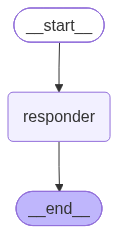

In [14]:
builder = StateGraph(EstadoConversa)

builder.add_node("responder", responder)

builder.add_edge(START, "responder")
builder.add_edge("responder", END)

grafo_checkpoint = builder.compile(checkpointer=checkpointer)

display_graph(grafo_checkpoint)

## 4.3 Conversa com `thread_id`

As duas chamadas da seção 1 são repetidas, agora com o mesmo `thread_id` no `config`. O `config` vai como segundo argumento de `invoke`, e a entrada continua com uma única mensagem por chamada.

In [15]:
config_renan = {"configurable": {"thread_id": "renan-01"}}

resultado_1 = grafo_checkpoint.invoke(
    {"messages": [HumanMessage(content="Oi, meu nome é Renan e estou no módulo A6.")]},
    config_renan,
)

mostrar_resposta(resultado_1)

Oi Renan! Que bom saber que você está no módulo A6. Como posso te ajudar hoje?


In [16]:
resultado_2 = grafo_checkpoint.invoke(
    {"messages": [HumanMessage(content="Qual é o meu nome e em qual módulo eu estou?")]},
    config_renan,
)

print("Mensagens no estado final:", len(resultado_2["messages"]))
mostrar_resposta(resultado_2)

Mensagens no estado final: 4
Seu nome é Renan e você está no módulo A6.


A pergunta abaixo vai para o mesmo grafo com outro `thread_id`, `ana-01`, que não tem checkpoints.

In [17]:
config_ana = {"configurable": {"thread_id": "ana-01"}}

resultado_ana = grafo_checkpoint.invoke(
    {"messages": [HumanMessage(content="Qual é o meu nome?")]},
    config_ana,
)

print("Mensagens no estado final:", len(resultado_ana["messages"]))
mostrar_resposta(resultado_ana)

Mensagens no estado final: 2
Desculpe, não sei seu nome. Poderia me dizer, por favor?


## 4.4 Leitura da execução

1. A primeira chamada em `renan-01` não encontra checkpoint. O estado começa com a apresentação, recebe a resposta, e o checkpointer grava o estado com duas mensagens.
2. A segunda chamada em `renan-01` carrega esse estado e acrescenta a pergunta. O nó `responder` envia ao modelo as três mensagens, e o estado final tem quatro. O modelo responde com o nome e o módulo, lidos da primeira mensagem do histórico.
3. A chamada em `ana-01` não encontra checkpoint dessa thread. O estado final tem duas mensagens, e o modelo responde que não tem o nome da aluna.

## 4.5 Inspeção dos checkpoints

O método `get_state` devolve o último checkpoint de uma thread como um `StateSnapshot`. O campo `values` traz o estado, e `next` traz os nós que executariam em seguida, vazio quando a execução chegou a `END`.

In [18]:
snapshot = grafo_checkpoint.get_state(config_renan)

print("Próximos nós:", snapshot.next)
print("Mensagens gravadas:", len(snapshot.values["messages"]))

for mensagem in snapshot.values["messages"]:
    print(f"  [{type(mensagem).__name__}] {mensagem.text[:80]}")

Próximos nós: ()
Mensagens gravadas: 4
  [HumanMessage] Oi, meu nome é Renan e estou no módulo A6.
  [AIMessage] Oi Renan! Que bom saber que você está no módulo A6. Como posso te ajudar hoje?
  [HumanMessage] Qual é o meu nome e em qual módulo eu estou?
  [AIMessage] Seu nome é Renan e você está no módulo A6.


O método `get_state_history` devolve todos os checkpoints da thread, do mais recente para o mais antigo. O campo `metadata` registra o passo (`step`) e a origem do checkpoint (`source`): `input` para o checkpoint gravado ao receber a entrada, `loop` para os gravados ao longo da execução.

In [19]:
for indice, checkpoint in enumerate(grafo_checkpoint.get_state_history(config_renan)):
    passo = checkpoint.metadata["step"]
    origem = checkpoint.metadata["source"]
    total = len(checkpoint.values.get("messages", []))

    print(f"Checkpoint {indice}: step={passo:>2} source={origem:<5} mensagens={total} next={checkpoint.next}")

Checkpoint 0: step= 4 source=loop  mensagens=4 next=()
Checkpoint 1: step= 3 source=loop  mensagens=3 next=('responder',)
Checkpoint 2: step= 2 source=input mensagens=2 next=('__start__',)
Checkpoint 3: step= 1 source=loop  mensagens=2 next=()
Checkpoint 4: step= 0 source=loop  mensagens=1 next=('responder',)
Checkpoint 5: step=-1 source=input mensagens=0 next=('__start__',)


Cada chamada a `invoke` gravou três checkpoints: o de `source=input`, antes de a entrada ser aplicada; o de `step` seguinte, com a entrada aplicada e `responder` em `next`; e o último, depois de `responder`, com `next` vazio. As duas chamadas em `renan-01` somam seis. O `step` continua a contagem da chamada anterior, de −1 a 4, porque a segunda chamada parte do último checkpoint da primeira.

## 4.6 Arquivo SQLite

O `SqliteSaver` cria duas tabelas no arquivo: `checkpoints`, com uma linha por checkpoint, e `writes`, com as atualizações pendentes de cada passo. A consulta abaixo lê o arquivo pela conexão aberta na seção 4.1, sem passar pelo LangGraph.

In [20]:
cursor = conexao_checkpoints.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type = 'table'")
print("Tabelas:", [linha[0] for linha in cursor.fetchall()])

cursor.execute("SELECT thread_id, COUNT(*) FROM checkpoints GROUP BY thread_id")
print("Checkpoints por thread:", cursor.fetchall())

Tabelas: ['checkpoints', 'writes']
Checkpoints por thread: [('ana-01', 3), ('renan-01', 6)]


O arquivo permanece no disco depois que a conexão é fechada. A célula abaixo abre uma segunda conexão com o mesmo arquivo, cria outro `SqliteSaver` e compila o mesmo `builder` com ele, as três operações que um processo novo faria para retomar a conversa de Renan.

In [21]:
conexao_nova = sqlite3.connect(ARQUIVO_CHECKPOINTS, check_same_thread=False)
grafo_retomado = builder.compile(checkpointer=SqliteSaver(conexao_nova))

snapshot_retomado = grafo_retomado.get_state(config_renan)

print("Mensagens lidas pela conexão nova:", len(snapshot_retomado.values["messages"]))
print("Primeira mensagem:", snapshot_retomado.values["messages"][0].text)

conexao_nova.close()

Mensagens lidas pela conexão nova: 4
Primeira mensagem: Oi, meu nome é Renan e estou no módulo A6.


## 4.7 Discussão

- O checkpointer grava o estado inteiro. Um campo acrescentado a `EstadoConversa` seria gravado e carregado junto com `messages`.
- O `thread_id` é a única chave que separa uma conversa de outra no checkpointer. Duas chamadas com o mesmo `thread_id` compartilham o histórico, mesmo que venham de alunos diferentes.
- O `InMemorySaver`, do pacote `langgraph-checkpoint`, e o `PostgresSaver` têm a mesma interface do `SqliteSaver`. O primeiro guarda os checkpoints na memória do processo, que se perde quando o kernel reinicia, e o segundo grava em PostgreSQL.
- Uma sessão nova de Renan, com outro `thread_id`, começa sem o nome e o módulo, porque as threads não compartilham checkpoints. A seção 5 grava essa informação fora das threads.

---

# 5. Memória de longo prazo

Um **store** grava registros JSON identificados por um **namespace**, uma tupla de strings, e por uma chave dentro dele. Os registros são gravados e lidos pelo código da aplicação, pelas operações `put`, `get` e `search`, e não dependem de `thread_id`. Um nó de qualquer thread lê o mesmo registro se usar o mesmo namespace e a mesma chave. A documentação do LangGraph chama isso de memória de **longo prazo**.

| | Checkpointer | Store |
|---|---|---|
| Chave de acesso | `thread_id` | namespace e chave |
| O que grava | o estado inteiro, a cada super-step | os registros passados a `put` |
| Quem grava | o LangGraph, durante a execução | o código da aplicação ou de um nó |
| Lido em uma thread nova | não | sim |
| Uso nesta aula | histórico de uma sessão | perfil do aluno e episódios de sessões anteriores |

## 5.1 Criação do `SqliteStore`

O `SqliteStore` também grava em um arquivo SQLite, apagado por `apagar_banco` antes da abertura, como na seção 4.1. Ele exige uma chamada a `setup()` antes do primeiro uso, que cria as tabelas. A conexão leva `check_same_thread=False` porque nós executados no mesmo super-step rodam em threads diferentes da que abriu a conexão.

**Atenção:** o `SqliteStore` abre e fecha as próprias transações com `BEGIN` e `COMMIT`. No modo padrão, o módulo `sqlite3` também abre uma transação antes de cada escrita, e a combinação das duas termina em `OperationalError: cannot start a transaction within a transaction`. A conexão do store é aberta com `isolation_level=None`, que desliga a transação implícita do `sqlite3`.

In [22]:
ARQUIVO_STORE = Path("memoria_longo_prazo.db")
apagar_banco(ARQUIVO_STORE)

conexao_store = sqlite3.connect(
    ARQUIVO_STORE,
    check_same_thread=False,
    isolation_level=None,  # o SqliteStore abre e fecha as próprias transações
)
store = SqliteStore(conexao_store)
store.setup()

print(type(store).__name__, "|", ARQUIVO_STORE)

SqliteStore | memoria_longo_prazo.db


## 5.2 Operações `put`, `get` e `search`

`put` recebe o namespace, a chave e o valor, que é um dicionário. `get` recebe o namespace e a chave e devolve um `Item`, com o valor no atributo `value`, ou `None` quando a chave não existe.

```text
namespace = ("perfil_aluno", "renan")
chave     = "dados"
valor     = {"modulo_atual": "A6", "idioma": "pt"}
```

In [23]:
store.put(("perfil_aluno", "renan"), "dados", {"modulo_atual": "A6", "idioma": "pt"})

item = store.get(("perfil_aluno", "renan"), "dados")

print(item.value)
print(store.get(("perfil_aluno", "renan"), "chave_inexistente"))

{'modulo_atual': 'A6', 'idioma': 'pt'}
None


`search` recebe um prefixo de namespace e devolve os itens de todos os namespaces que começam por ele. Os itens vêm do atualizado mais recentemente para o mais antigo, pelo campo `updated_at`, que o `SqliteStore` grava com resolução de segundos; itens gravados no mesmo segundo não têm ordem de recência entre si. O parâmetro `limit` vale 10 por padrão, e um namespace com mais de dez itens é cortado nos dez primeiros dessa ordem.

In [24]:
store.put(("perfil_aluno", "ana"), "dados", {"modulo_atual": "A5", "idioma": "en"})

for item in store.search(("perfil_aluno",)):
    print(item.namespace, "->", item.value)

('perfil_aluno', 'ana') -> {'modulo_atual': 'A5', 'idioma': 'en'}
('perfil_aluno', 'renan') -> {'modulo_atual': 'A6', 'idioma': 'pt'}


## 5.3 Perfil do aluno

A documentação do LangGraph separa a memória de longo prazo pelo conteúdo e pela organização. Pelo conteúdo, a memória **semântica** guarda fatos, como o módulo em que o aluno está, e a memória **episódica** guarda experiências, como as sessões anteriores. Pela organização, um **perfil** é um documento único por entidade, reescrito a cada atualização, e uma **coleção** é um conjunto de documentos, um por chave, que cresce a cada registro.

O perfil do aluno usa uma chave fixa, `"dados"`. Um `put` com o mesmo namespace e a mesma chave substitui o valor anterior, e o namespace continua com um item.

In [25]:
def salvar_perfil_aluno(aluno: str, modulo_atual: str, modulos_concluidos: list[str]) -> None:
    """Grava o perfil do aluno, substituindo o anterior."""
    store.put(
        ("perfil_aluno", aluno.lower()),
        "dados",
        {
            "modulo_atual": modulo_atual,
            "modulos_concluidos": modulos_concluidos,
            "atualizado_em": datetime.now().isoformat(timespec="seconds"),
        },
    )


salvar_perfil_aluno("Renan", "A5", ["A4"])
salvar_perfil_aluno("Renan", "A6", ["A4", "A5"])
salvar_perfil_aluno("Ana", "A5", ["A4"])

perfis_renan = store.search(("perfil_aluno", "renan"))

print("Itens no namespace de Renan:", len(perfis_renan))
print(perfis_renan[0].value)

Itens no namespace de Renan: 1
{'modulo_atual': 'A6', 'modulos_concluidos': ['A4', 'A5'], 'atualizado_em': '2026-09-28T09:06:43'}


## 5.4 Episódios de sessões anteriores

Os episódios formam uma coleção: cada registro vira um documento com chave própria, gerada por `uuid4`, no namespace `("episodios", <aluno>)`. Um episódio novo não substitui os anteriores. Cada episódio guarda também a sessão em que ocorreu, pelo `thread_id` dela, para que o tutor distinga os assuntos de sessões diferentes.

In [26]:
def salvar_episodio(aluno: str, sessao: str, resumo: str) -> None:
    """Acrescenta um episódio à coleção do aluno, com chave nova."""
    store.put(
        ("episodios", aluno.lower()),
        str(uuid.uuid4()),
        {
            "sessao": sessao,
            "resumo": resumo,
            "quando": datetime.now().isoformat(timespec="seconds"),
        },
    )


salvar_episodio("Renan", "renan-sessao-0", "Perguntou sobre reducers e sobre o funcionamento de add_messages.")
salvar_episodio("Renan", "renan-sessao-0", "Pediu ajuda para montar um roteador de intenção com LLM.")

episodios_renan = store.search(("episodios", "renan"))

print("Itens no namespace de episódios de Renan:", len(episodios_renan))

for episodio in episodios_renan:
    print(episodio.value["quando"], episodio.value["sessao"], "-", episodio.value["resumo"])

Itens no namespace de episódios de Renan: 2
2026-09-28T09:06:43 renan-sessao-0 - Perguntou sobre reducers e sobre o funcionamento de add_messages.
2026-09-28T09:06:43 renan-sessao-0 - Pediu ajuda para montar um roteador de intenção com LLM.


## 5.5 Discussão

| | Perfil | Coleção de episódios |
|---|---|---|
| Chave | fixa (`"dados"`) | uma por registro (`uuid4`) |
| Efeito de um `put` novo | substitui o valor | acrescenta um item |
| Leitura | `get` com a chave | `search` com o namespace |
| Tamanho do namespace | um item | cresce a cada sessão |

As duas organizações usam a mesma API do store e diferem na escolha da chave. O custo da coleção aparece na leitura: o `search` devolve no máximo `limit` itens, e o texto dos episódios lidos entra no prompt de cada chamada ao modelo. O perfil tem o custo na escrita, porque uma atualização precisa partir do valor anterior para não perder campos.

## 5.6 Store dentro de um nó

Um grafo compilado com `builder.compile(store=store)` entrega o store aos nós em `runtime.store`, no mesmo objeto `Runtime` que traz o contexto da seção 3. O nome do aluno vem de `runtime.context.aluno` e seleciona os namespaces lidos. A função `carregar_memoria_aluno` monta o texto do perfil e dos episódios, e o nó `responder_com_memoria` o acrescenta à instrução do tutor antes de chamar o modelo.

In [27]:
def carregar_memoria_aluno(store: BaseStore, aluno: str) -> str:
    """Monta o texto do perfil e dos episódios do aluno lidos do store."""
    perfil = store.get(("perfil_aluno", aluno), "dados")
    episodios = store.search(("episodios", aluno))

    if perfil is None:
        texto_perfil = "Nenhum perfil registrado."
    else:
        concluidos = ", ".join(perfil.value["modulos_concluidos"]) or "nenhum"
        texto_perfil = f"Módulo atual: {perfil.value['modulo_atual']}. Módulos concluídos: {concluidos}."

    linhas_episodios = [
        f"- {ep.value['quando']}, sessão {ep.value['sessao']}: {ep.value['resumo']}" for ep in episodios
    ]
    texto_episodios = "\n".join(linhas_episodios) or "Nenhuma sessão anterior registrada."

    return f"Perfil do aluno: {texto_perfil}\nSessões anteriores:\n{texto_episodios}"


def responder_com_memoria(state: EstadoConversa, runtime: Runtime[ContextoCurso]) -> dict:
    """Chama o modelo com a instrução do tutor e a memória de longo prazo do aluno."""
    memoria = carregar_memoria_aluno(runtime.store, runtime.context.aluno.lower())
    instrucao = f"{INSTRUCAO_TUTOR}\n\nO aluno se chama {runtime.context.aluno}.\n{memoria}"

    resposta = modelo.invoke([SystemMessage(content=instrucao), *state["messages"]])

    return {"messages": [resposta]}


print(carregar_memoria_aluno(store, "renan"))

Perfil do aluno: Módulo atual: A6. Módulos concluídos: A4, A5.
Sessões anteriores:
- 2026-09-28T09:06:43, sessão renan-sessao-0: Perguntou sobre reducers e sobre o funcionamento de add_messages.
- 2026-09-28T09:06:43, sessão renan-sessao-0: Pediu ajuda para montar um roteador de intenção com LLM.


O grafo tem um nó e é compilado apenas com o store, sem checkpointer.

Bom dia, Renan! Você está no módulo A6, tendo concluído os módulos A4 e A5. Nas sessões anteriores você perguntou sobre reducers e o funcionamento de add_messages, e pediu ajuda para montar um roteador de intenção com LLM.


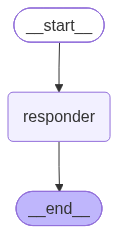

In [28]:
builder = StateGraph(EstadoConversa, context_schema=ContextoCurso)

builder.add_node("responder", responder_com_memoria)

builder.add_edge(START, "responder")
builder.add_edge("responder", END)

grafo_store = builder.compile(store=store)

resultado = grafo_store.invoke(
    {"messages": [HumanMessage(content="Bom dia! Em que módulo eu estou e sobre o que já conversamos?")]},
    context=ContextoCurso(aluno="Renan"),
)

mostrar_resposta(resultado)
display_graph(grafo_store)

## 5.7 Leitura da execução

1. O `invoke` recebe uma mensagem e o contexto com `aluno="Renan"`. Não há `thread_id` nem checkpointer, e o estado começa só com a pergunta, como na seção 1.
2. O nó lê `runtime.context.aluno`, e `carregar_memoria_aluno` busca o perfil em `("perfil_aluno", "renan")` e os episódios em `("episodios", "renan")`.
3. A instrução enviada ao modelo traz o módulo `A6`, os módulos concluídos e os dois episódios gravados na seção 5.4.
4. O modelo responde com o módulo e os assuntos das sessões anteriores, lidos da instrução. A pergunta não contém nenhum desses dados.

---

# 6. Agente com as duas memórias

O grafo desta seção é compilado com o checkpointer da seção 4 e o store da seção 5, e tem dois nós. `responder` é o nó `responder_com_memoria` da seção 5.6, que lê o store. `registrar_episodio` grava no store um episódio com a última pergunta do aluno, depois de cada resposta, e o nó `responder` da sessão seguinte lê esses episódios.

```text
config  → thread_id  → checkpointer: histórico da sessão atual
context → aluno      → store: perfil e episódios de sessões anteriores

START → responder → registrar_episodio → END
          ↑ lê o store      ↓ grava no store
```

O resumo do episódio é a própria pergunta, recortada em 120 caracteres. Um resumo escrito pelo modelo exigiria uma segunda chamada por turno. A sessão do episódio é o `thread_id` da execução, lido em `runtime.execution_info.thread_id`, conforme a seção 3.2.

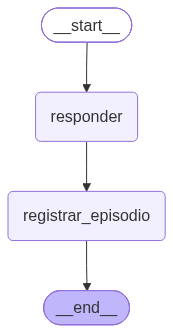

In [29]:
def registrar_episodio(state: EstadoConversa, runtime: Runtime[ContextoCurso]) -> dict:
    """Grava no store um episódio com a última pergunta do aluno."""
    pergunta = next(m for m in reversed(state["messages"]) if isinstance(m, HumanMessage))

    runtime.store.put(
        ("episodios", runtime.context.aluno.lower()),
        str(uuid.uuid4()),
        {
            "sessao": runtime.execution_info.thread_id,
            "resumo": f"Perguntou: {pergunta.text[:120]}",
            "quando": datetime.now().isoformat(timespec="seconds"),
        },
    )

    return {}


builder = StateGraph(EstadoConversa, context_schema=ContextoCurso)

builder.add_node("responder", responder_com_memoria)
builder.add_node("registrar_episodio", registrar_episodio)

builder.add_edge(START, "responder")
builder.add_edge("responder", "registrar_episodio")
builder.add_edge("registrar_episodio", END)

grafo_completo = builder.compile(checkpointer=checkpointer, store=store)

display_graph(grafo_completo)

A primeira sessão de Renan tem dois turnos na thread `renan-sessao-1`. O segundo turno pergunta por um dado dito no primeiro, que só está no histórico da thread.

In [30]:
config_sessao_1 = {"configurable": {"thread_id": "renan-sessao-1"}}
contexto_renan = ContextoCurso(aluno="Renan")

perguntas_sessao_1 = [
    "Hoje quero revisar checkpointers. Qual é o papel do thread_id?",
    "Qual tema eu disse que queria revisar hoje?",
]

for pergunta in perguntas_sessao_1:
    resultado = grafo_completo.invoke(
        {"messages": [HumanMessage(content=pergunta)]},
        config_sessao_1,
        context=contexto_renan,
    )

    print("Aluno:", pergunta)
    print("Tutor:", resultado["messages"][-1].text)
    print("-" * 60)

print("Mensagens na thread renan-sessao-1:", len(resultado["messages"]))

Aluno: Hoje quero revisar checkpointers. Qual é o papel do thread_id?
Tutor: O `thread_id` identifica de forma única a conversa (ou “thread”) à qual o checkpoint pertence, permitindo que o sistema recupere e continue exatamente o mesmo fluxo de mensagens. Cada thread tem seu próprio conjunto de checkpoints, de modo que alterações em uma conversa não interferem nas demais. Assim, ao restaurar um checkpoint, o LLM usa o `thread_id` para carregar o estado correto daquela conversa.
------------------------------------------------------------


Aluno: Qual tema eu disse que queria revisar hoje?
Tutor: Você disse que quer revisar **checkpointers**.
------------------------------------------------------------
Mensagens na thread renan-sessao-1: 4


A segunda sessão usa outra thread, `renan-sessao-2`, e começa sem histórico no checkpointer.

In [31]:
config_sessao_2 = {"configurable": {"thread_id": "renan-sessao-2"}}

resultado = grafo_completo.invoke(
    {"messages": [HumanMessage(content="O que eu revisei na última sessão?")]},
    config_sessao_2,
    context=contexto_renan,
)

print("Mensagens na thread renan-sessao-2:", len(resultado["messages"]))
mostrar_resposta(resultado)

print("\nEpisódios de Renan no store:", len(store.search(("episodios", "renan"))))

Mensagens na thread renan-sessao-2: 2
Na última sessão você revisou o tema dos **checkpointers**, especificamente o papel do **thread_id** dentro deles.

Episódios de Renan no store: 5


## 6.1 Leitura da execução

1. O primeiro turno de `renan-sessao-1` não encontra checkpoint. O nó `responder` lê do store o perfil e os dois episódios da seção 5.4, e responde sobre o `thread_id`. O nó `registrar_episodio` grava o terceiro episódio.
2. O segundo turno carrega o checkpoint da thread, com a pergunta e a resposta do primeiro. O modelo responde que o tema é checkpointers, lido do histórico. O nó `registrar_episodio` grava o quarto episódio, e a thread fica com quatro mensagens.
3. A chamada em `renan-sessao-2` não encontra checkpoint, e a thread termina com duas mensagens. A pergunta sobre a última sessão é respondida pelos episódios marcados com `renan-sessao-1`, gravados no store pelos dois turnos da sessão anterior. Os episódios de `renan-sessao-0` também estão na instrução, e a marca de sessão os separa.
4. O store termina com cinco episódios de Renan: dois gravados pela seção 5.4 e três pelo nó `registrar_episodio`, um por turno.

## 6.2 Discussão

Cada pergunta da execução depende de uma das duas memórias. O segundo turno da sessão 1 depende do checkpointer, porque o tema citado na pergunta anterior está só no histórico da thread. A pergunta da sessão 2 depende do store, porque a thread nova não tem histórico e a sessão anterior deixou os episódios no namespace do aluno.

```text
checkpointer → memória dentro de uma thread (chave: thread_id)
store        → memória entre threads         (chave: namespace e chave do item)
```

O nó `registrar_episodio` grava a memória durante a execução, antes de o grafo devolver o resultado. A documentação do LangGraph chama isso de escrita no *hot path*, e a alternativa é uma tarefa separada que lê as conversas encerradas e grava os episódios depois. A gravação durante a execução deixa o episódio disponível para a próxima sessão e acrescenta o tempo da escrita a cada turno.

---

# 7. Exercícios de fixação

Os exercícios rodam depois de todas as células do notebook, com `checkpointer`, `store`, `grafo_completo` e as funções das seções 4 a 6 definidos. Os exercícios 1 e 3 constroem grafos novos a partir dessas peças, e os exercícios 2 e 4 usam `grafo_completo` como está.

## Exercício 1 — Nível do aluno no contexto

Redefina `ContextoCurso` com um campo `nivel`, de valor `"iniciante"` ou `"avancado"` e padrão `"iniciante"`, e redefina `responder_com_memoria` para acrescentar à instrução uma linha que ajuste a explicação ao nível. O `StateGraph` guarda o `context_schema` e a função do nó no momento da construção, então reconstrua o `builder` da seção 6 e compile um grafo novo com o checkpointer e o store. Envie a pergunta `"O que é um checkpointer?"` duas vezes, cada uma em uma thread nova e com um nível diferente, e compare as respostas.

## Exercício 2 — Sessões da Ana

Escreva uma função `nova_sessao() -> RunnableConfig` que devolve um `config` com um `thread_id` gerado por `uuid.uuid4()`. Abra duas sessões da Ana em `grafo_completo`, com `context=ContextoCurso(aluno="Ana")`, e envie `"Meu projeto final é um tutor de Python."` na primeira e `"Qual é o meu projeto final?"` na segunda. Imprima, com `grafo_completo.get_state`, o número de mensagens de cada thread e, com `store.search(("episodios", "ana"))`, os episódios da Ana, e identifique qual das duas memórias levou o projeto da primeira sessão para a segunda.

## Exercício 3 — Atualização do perfil por um nó

Escreva um nó `atualizar_progresso` que procure na última mensagem do aluno o padrão `concluí o módulo A<n>` (importe `re` e use `re.search` com `re.IGNORECASE`) e, quando o encontrar, grave com `runtime.store.put` o perfil com o módulo acrescentado a `modulos_concluidos` e `modulo_atual` igual ao módulo seguinte. O nó parte do perfil lido com `runtime.store.get`, para não perder os campos anteriores. Monte um grafo `START → atualizar_progresso → responder → END`, com `responder_com_memoria` no nó `responder`, compile-o com o checkpointer e o store, envie `"Concluí o módulo A6 hoje."` com o contexto de Renan, e imprima o perfil antes e depois.

## Exercício 4 — Limite de episódios

O store tem pelo menos cinco episódios de Renan, gravados nas seções 5.4 e 6. Redefina `carregar_memoria_aluno` para ler no máximo os três episódios atualizados mais recentemente, com o parâmetro `limit` de `search`, e imprima `carregar_memoria_aluno(store, "renan")` antes e depois da alteração. O nó `responder_com_memoria` procura a função pelo nome a cada execução, então `grafo_completo` passa a usar a versão nova sem ser recompilado.

## Exercício 5 — Preferência do aluno

Sem rodar código, responda: o aluno escreve, na primeira mensagem de uma sessão, `"Inclua um exemplo de código em cada resposta."`. Com `grafo_completo` como está, descreva por qual caminho esse pedido chega ao modelo no segundo turno da mesma sessão e no primeiro turno de uma sessão nova, considerando o que os nós `responder` e `registrar_episodio` leem e gravam. Explique por que o caminho da sessão nova deixa de funcionar depois de dez episódios mais recentes, e indique em qual namespace, com qual chave e em qual das duas organizações da seção 5.5 o pedido precisaria ser gravado para valer em todas as sessões seguintes.

---

# 8. Resumo da aula

O notebook partiu de um grafo cujo estado termina com a chamada a `invoke` e acrescentou os dois mecanismos de persistência do LangGraph, cada um com uma chave de acesso própria. O checkpointer usa o `thread_id`, entregue pelo `config`, e o store usa o namespace e a chave, montados a partir do nome do aluno entregue pelo contexto.

| Conceito | Ideia principal |
|---|---|
| Estado de uma execução | criado a partir da entrada de `invoke` e descartado ao final, sem checkpointer |
| `RunnableConfig` | dicionário passado a `invoke`; `configurable` leva valores da aplicação e o `thread_id` |
| `Runtime` e `context_schema` | contexto com campos declarados, lido em `runtime.context`; sem validação de tipo na execução |
| Checkpointer | grava o estado inteiro a cada super-step, sob o `thread_id`; memória de curto prazo |
| `get_state` e `get_state_history` | último checkpoint e lista de checkpoints de uma thread, três por `invoke` de um nó |
| Store | registros JSON por namespace e chave, lidos de qualquer thread; memória de longo prazo |
| Perfil | um documento por aluno, com chave fixa, substituído a cada `put` |
| Coleção de episódios | um documento por chave nova; `search` devolve até `limit` itens, 10 por padrão |
| `runtime.store` | store compilado com o grafo, lido e gravado pelos nós |

## 8.1 Checklist de compreensão

Questões de verificação:

1. Por que o reducer `add_messages` não leva as mensagens de uma chamada a `invoke` para a seguinte em um grafo sem checkpointer?
2. Qual é a diferença entre um valor lido de `config["configurable"]` e um lido de `runtime.context`, e o que acontece em cada caso com um nome de campo errado?
3. Por que o `thread_id` fica no `config`, e não no contexto?
4. Quantos checkpoints uma chamada a `invoke` grava em um grafo de um nó, e o que distingue cada um?
5. O que o checkpointer grava que o store não grava, e o contrário?
6. Como a escolha da chave distingue um perfil de uma coleção no mesmo store?
7. Quando um aluno tem onze episódios, qual deles fica fora do texto montado por `carregar_memoria_aluno`, e por quê?
8. No grafo da seção 6, qual memória responde à segunda pergunta da sessão 1, e qual responde à pergunta da sessão 2?

## 8.2 Próximos passos

- redução do histórico de uma thread longa, removendo ou resumindo mensagens antigas antes da chamada ao modelo;
- busca semântica no store, com um índice de embeddings e o parâmetro `query` de `search`;
- ferramentas de memória, chamadas pelo modelo para gravar e consultar registros no store;
- escrita da memória em segundo plano, fora do caminho da resposta;
- checkpointers e stores em PostgreSQL (`PostgresSaver` e `PostgresStore`), com a mesma interface.

# 9. Referências

- LangGraph, Memory overview: https://docs.langchain.com/oss/python/concepts/memory
- LangGraph, Add memory: https://docs.langchain.com/oss/python/langgraph/add-memory
- LangGraph, Persistence: https://docs.langchain.com/oss/python/langgraph/persistence
- LangGraph, Stores: https://docs.langchain.com/oss/python/langgraph/stores
- LangGraph, Runtime context: https://docs.langchain.com/oss/python/langgraph/graph-api#runtime-context
- Referência de `SqliteSaver`: https://reference.langchain.com/python/langgraph.checkpoint.sqlite/SqliteSaver
- Referência de `SqliteStore`: https://reference.langchain.com/python/langgraph/store